In [ ]:
# Summary report
print("\n" + "="*70)
print("FEATURE ENGINEERING ANALYSIS SUMMARY")
print("="*70)

print(f"\nTotal Features Engineered: {len(all_features)}")
print(f"Models Analyzed: {len(normalized_importances)}")

print("\n\nFEATURE CATEGORY STATISTICS:")
print("-"*70)
for category, features in feature_categories.items():
    feature_list = [f for f in features if f in all_features]
    if feature_list:
        avg_importance_by_cat = np.mean([normalized_importances[model][f] 
                                         for f in feature_list 
                                         for model in normalized_importances.keys()])
        print(f"\n{category.upper():}")
        print(f"  Count: {len(feature_list)} features")
        print(f"  Average Importance: {avg_importance_by_cat:.2f}%")
        print(f"  Top 3 Features:")
        top_cat_features = pd.Series({
            f: np.mean([normalized_importances[model][f] for model in normalized_importances.keys()])
            for f in feature_list
        }).sort_values(ascending=False).head(3)
        for feat, imp in top_cat_features.items():
            print(f"    - {feat}: {imp:.2f}%")

print("\n\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)

# Find consensus top features across models
consensus_features = avg_importance.head(5)
print("\nTop 5 Most Important Features (Consensus):")
for rank, (feature, importance) in enumerate(consensus_features.items(), 1):
    print(f"  {rank}. {feature} ({importance:.2f}%)")

# Find category consensus
print("\nMost Important Feature Categories:")
category_importances = {}
for category, features in feature_categories.items():
    feature_list = [f for f in features if f in all_features]
    if feature_list:
        cat_importance = np.mean([normalized_importances[model][f] 
                                  for f in feature_list 
                                  for model in normalized_importances.keys()])
        category_importances[category] = cat_importance

sorted_categories = sorted(category_importances.items(), key=lambda x: x[1], reverse=True)
for rank, (category, importance) in enumerate(sorted_categories, 1):
    print(f"  {rank}. {category.capitalize()}: {importance:.2f}%")

print("\n" + "="*70)

## 8. Summary & Insights

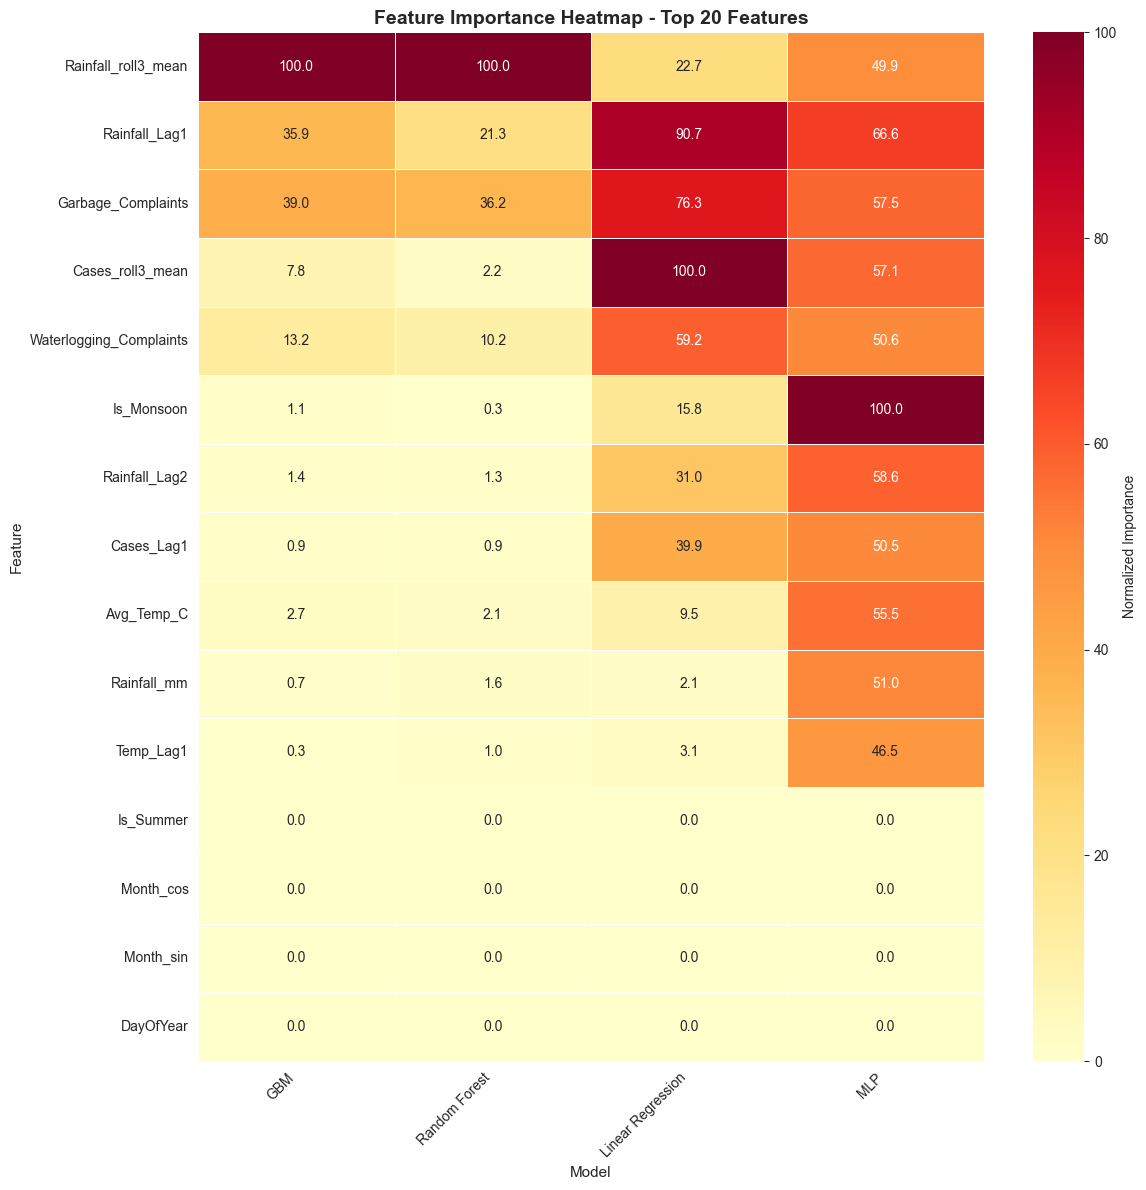


Top 20 Features by Average Importance Across All Models:
Rank   Feature                        Avg Importance      
----------------------------------------------------------------------
1      Rainfall_roll3_mean                      68.17%
2      Rainfall_Lag1                            53.62%
3      Garbage_Complaints                       52.24%
4      Cases_roll3_mean                         41.78%
5      Waterlogging_Complaints                  33.29%
6      Is_Monsoon                               29.30%
7      Rainfall_Lag2                            23.08%
8      Cases_Lag1                               23.07%
9      Avg_Temp_C                               17.46%
10     Rainfall_mm                              13.84%
11     Temp_Lag1                                12.73%
12     Is_Summer                                 0.00%
13     Month_cos                                 0.00%
14     Month_sin                                 0.00%
15     DayOfYear                          

In [11]:
# Create heatmap for top features across all models
top_n_features = 20
all_top_features = avg_importance.head(top_n_features).index

heatmap_data = pd.DataFrame({
    model: normalized_importances[model][all_top_features] 
    for model in normalized_importances.keys()
})

fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Normalized Importance'}, ax=ax, linewidths=0.5)
ax.set_title(f'Feature Importance Heatmap - Top {top_n_features} Features', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print feature statistics
print("\nTop 20 Features by Average Importance Across All Models:")
print("="*70)
print(f"{'Rank':<6} {'Feature':<30} {'Avg Importance':<20}")
print("-"*70)
for rank, (feature, importance) in enumerate(avg_importance.head(20).items(), 1):
    print(f"{rank:<6} {feature:<30} {importance:>15.2f}%")

## 7. Feature Importance Heatmap - All Models

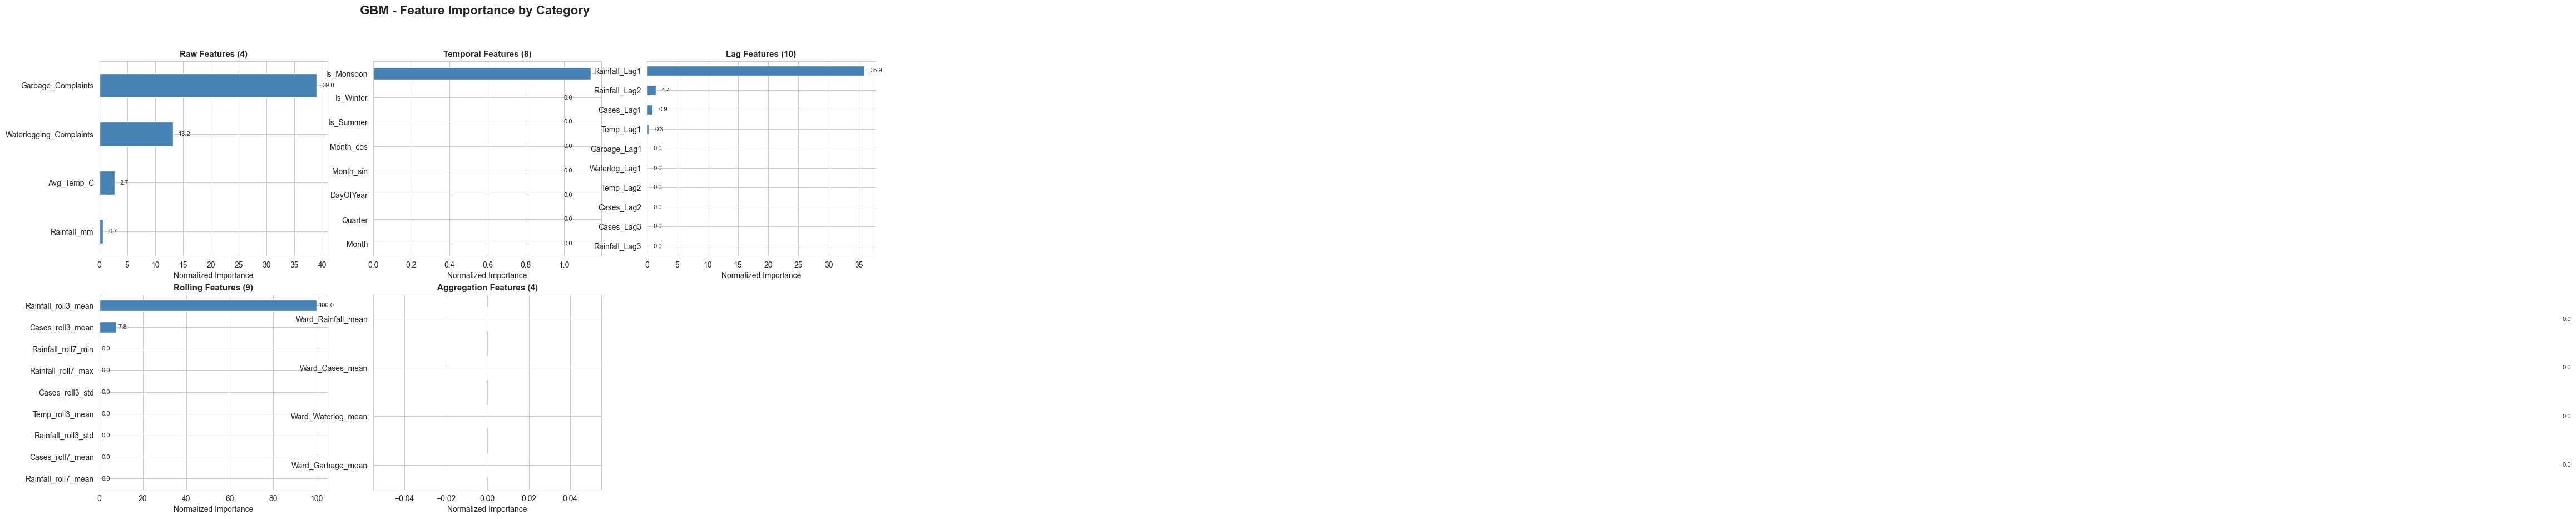

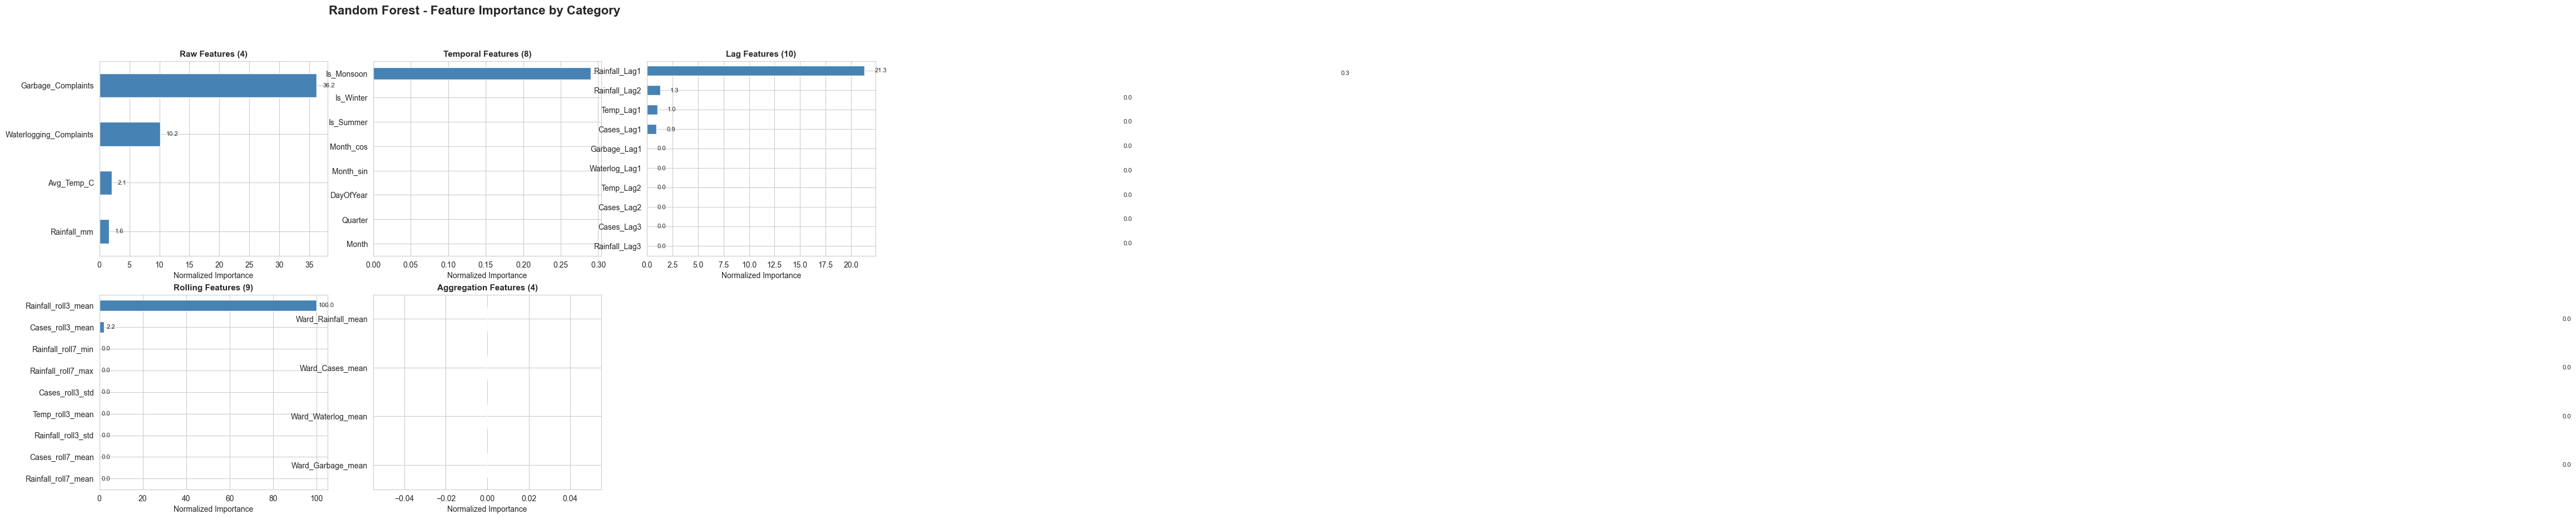

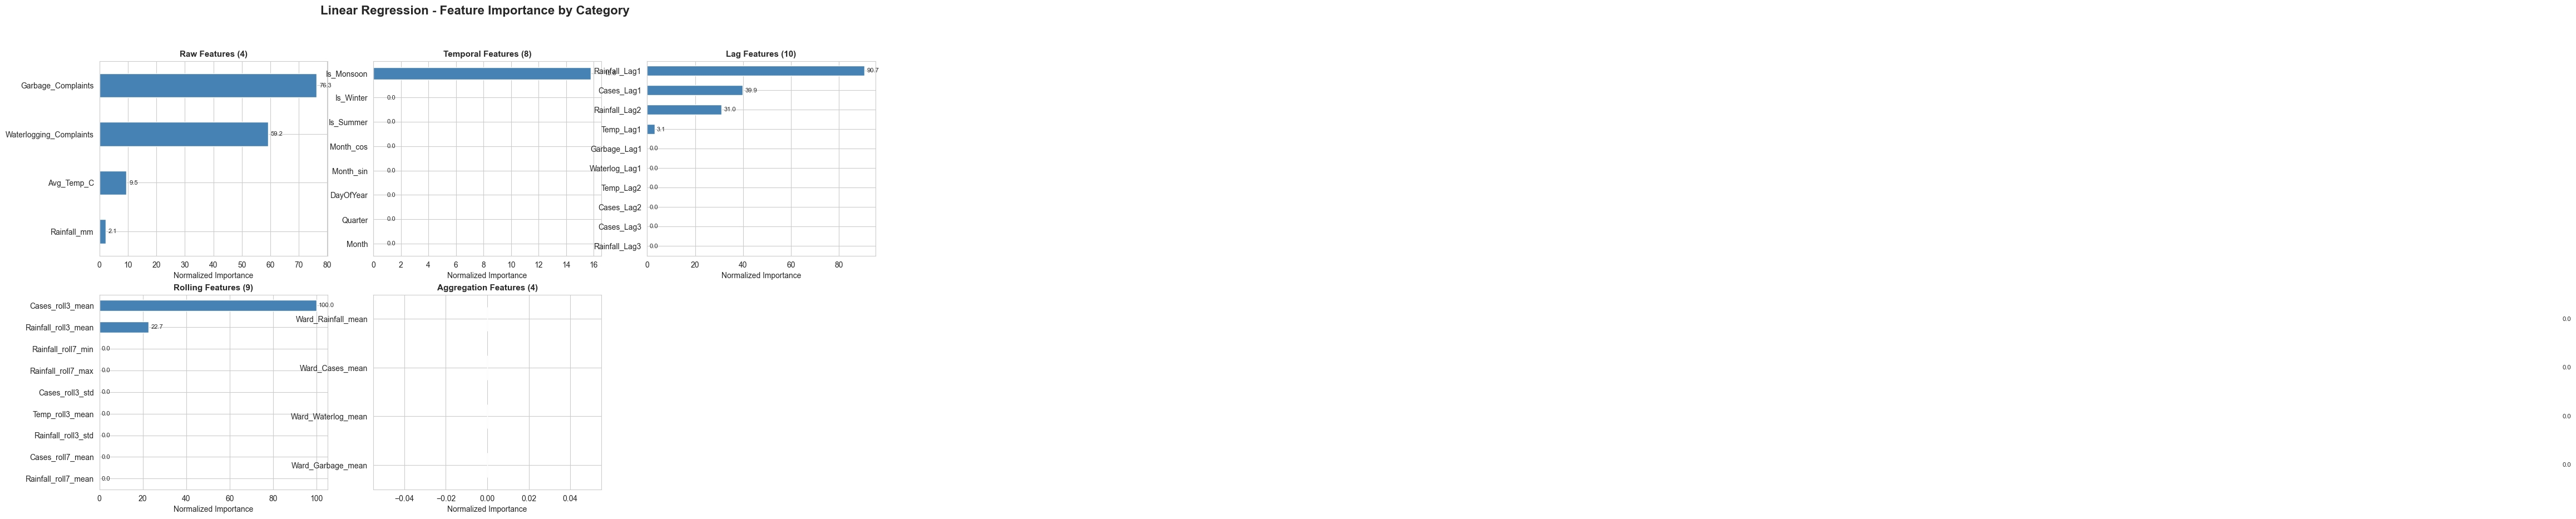

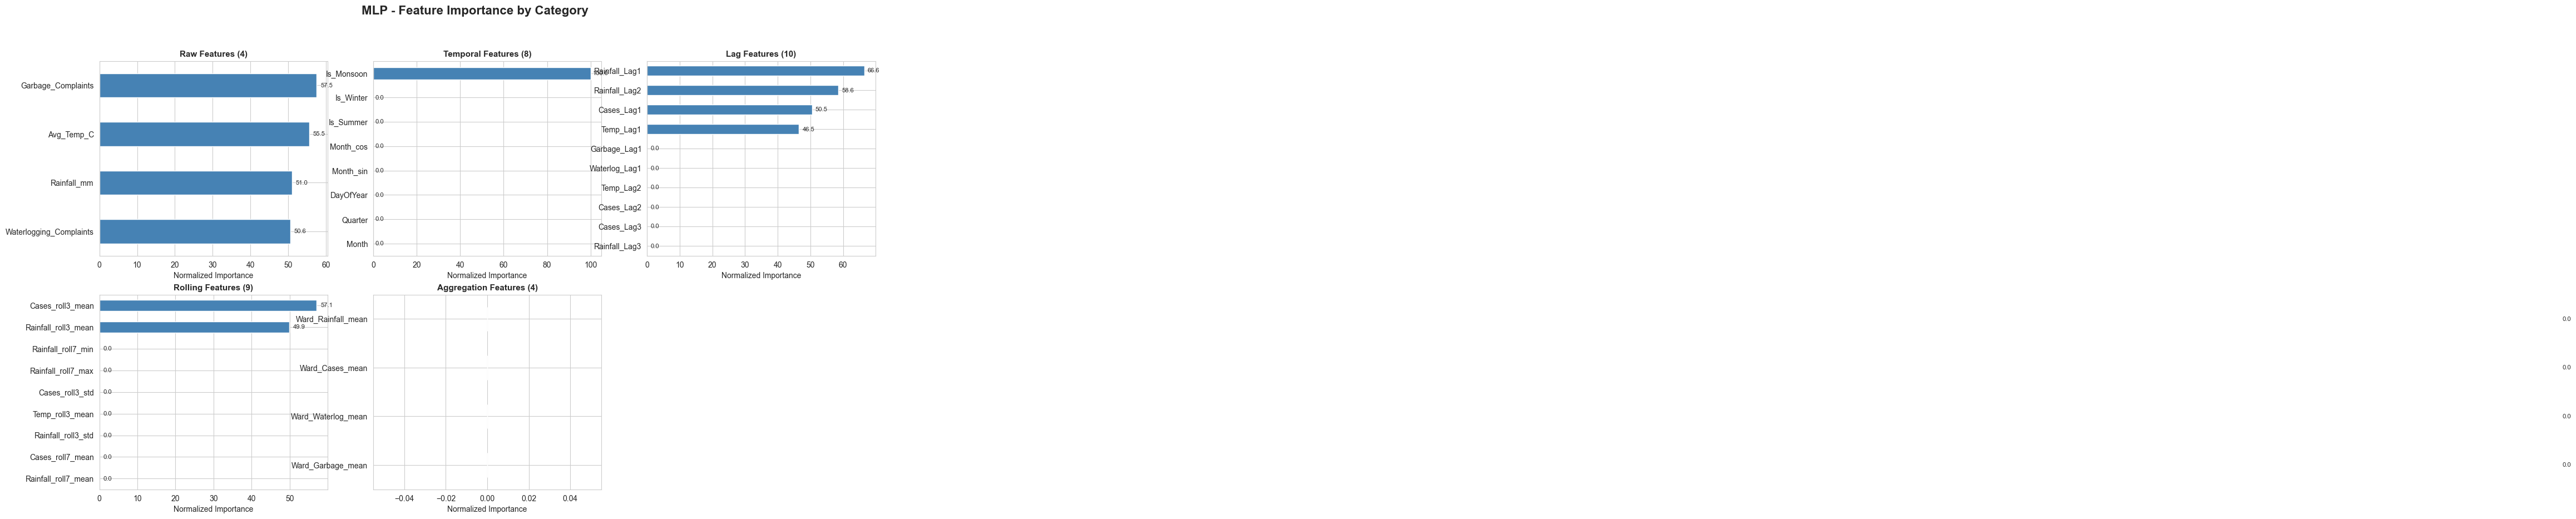

In [10]:
# Detailed category breakdown for each model
for model_name in normalized_importances.keys():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{model_name} - Feature Importance by Category', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    for cat_idx, (category, features) in enumerate(feature_categories.items()):
        ax = axes[cat_idx]
        
        # Get features in this category
        feature_list = [f for f in features if f in all_features]
        
        if feature_list:
            # Get importance for these features
            importance_data = pd.Series(
                {f: normalized_importances[model_name][f] for f in feature_list}
            ).sort_values(ascending=True)
            
            # Plot
            importance_data.plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'{category.capitalize()} Features ({len(feature_list)})', 
                        fontsize=11, fontweight='bold')
            ax.set_xlabel('Normalized Importance', fontsize=10)
            
            # Add value labels
            for i, v in enumerate(importance_data.values):
                ax.text(v + 1, i, f'{v:.1f}', va='center', fontsize=8)
    
    # Remove extra subplots
    for idx in range(len(feature_categories), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

## 6. Detailed Category Breakdown - Bar Charts

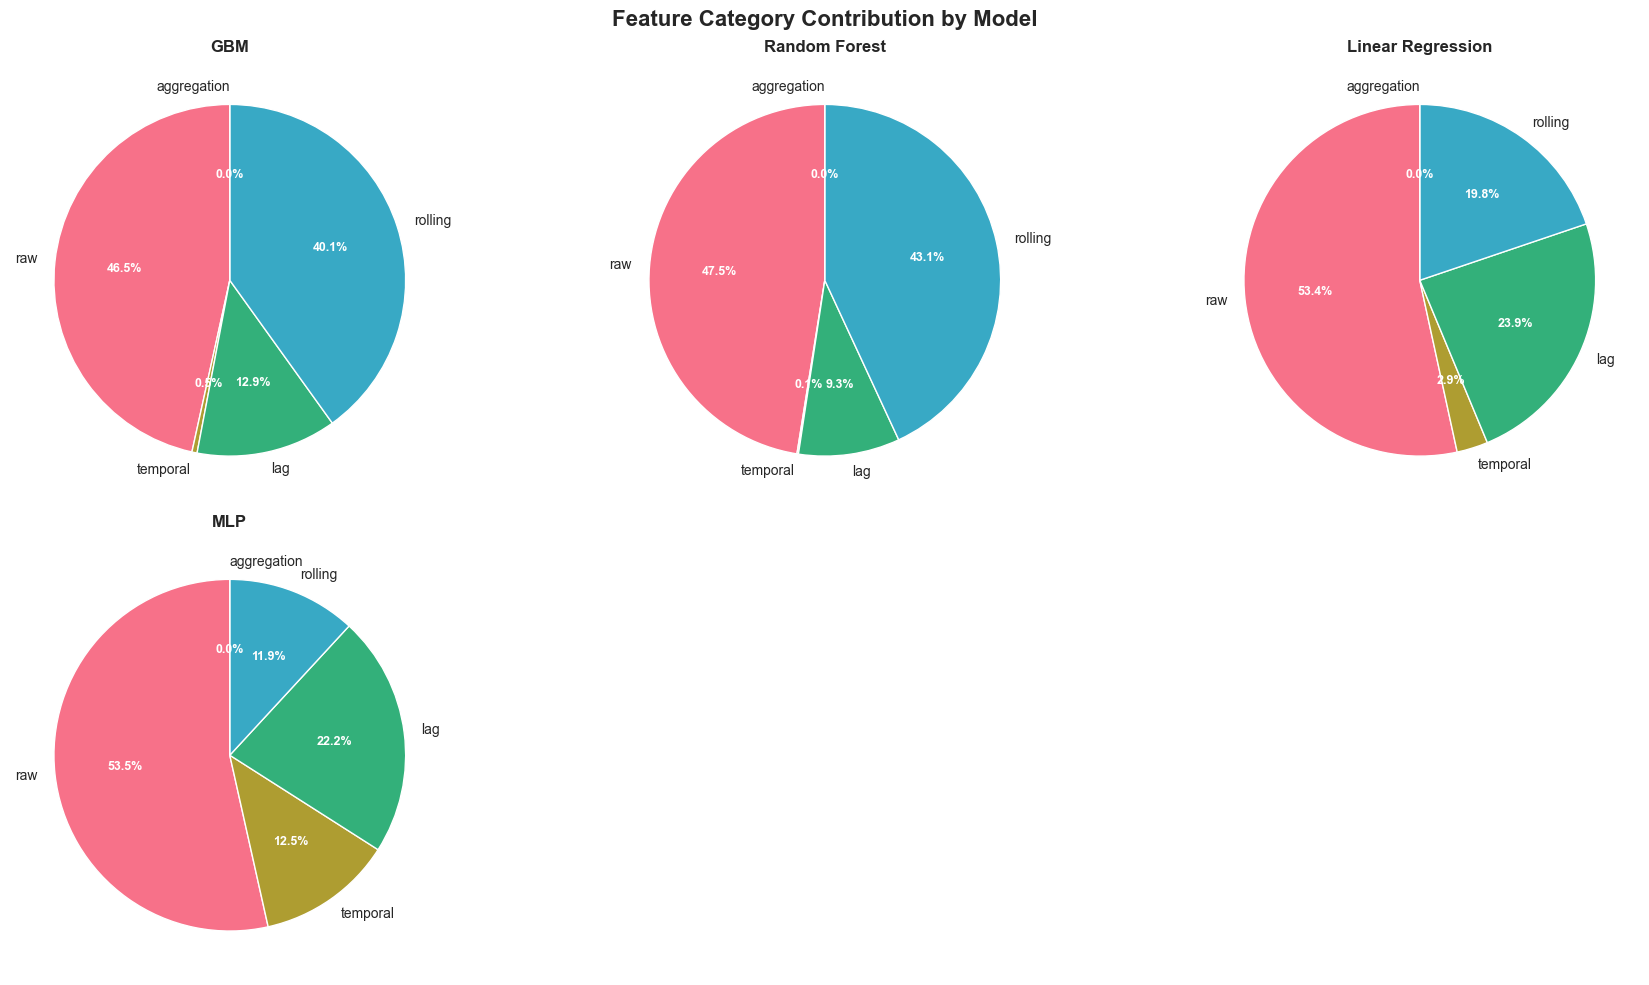


Feature Category Importance Summary:


GBM:
  raw: 13.90%
  rolling: 11.97%
  lag: 3.85%
  temporal: 0.14%
  aggregation: 0.00%

Random Forest:
  raw: 12.51%
  rolling: 11.36%
  lag: 2.45%
  temporal: 0.04%
  aggregation: 0.00%

Linear Regression:
  raw: 36.78%
  lag: 16.47%
  rolling: 13.64%
  temporal: 1.97%
  aggregation: 0.00%

MLP:
  raw: 53.65%
  lag: 22.22%
  temporal: 12.50%
  rolling: 11.90%
  aggregation: 0.00%


In [9]:
# Analyze feature category contribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Category Contribution by Model', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, model_name in enumerate(list(normalized_importances.keys())[:6]):
    ax = axes[idx]
    
    # Calculate category importance
    category_importance = {}
    for category, features in feature_categories.items():
        feature_list = [f for f in features if f in all_features]
        if feature_list:
            importance_values = [normalized_importances[model_name][f] for f in feature_list]
            category_importance[category] = np.mean(importance_values)
    
    # Create pie chart
    categories = list(category_importance.keys())
    values = list(category_importance.values())
    colors = sns.color_palette('husl', len(categories))
    
    wedges, texts, autotexts = ax.pie(values, labels=categories, autopct='%1.1f%%', 
                                        colors=colors, startangle=90)
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    
    # Format percentage text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)

# Remove extra subplots
for idx in range(len(normalized_importances), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Print category importance summary
print("\nFeature Category Importance Summary:\n")
for model_name in normalized_importances.keys():
    print(f"\n{model_name}:")
    category_importance = {}
    for category, features in feature_categories.items():
        feature_list = [f for f in features if f in all_features]
        if feature_list:
            importance_values = [normalized_importances[model_name][f] for f in feature_list]
            category_importance[category] = np.mean(importance_values)
    
    sorted_cats = sorted(category_importance.items(), key=lambda x: x[1], reverse=True)
    for cat, imp in sorted_cats:
        print(f"  {cat}: {imp:.2f}%")

## 5. Feature Category Contribution Analysis

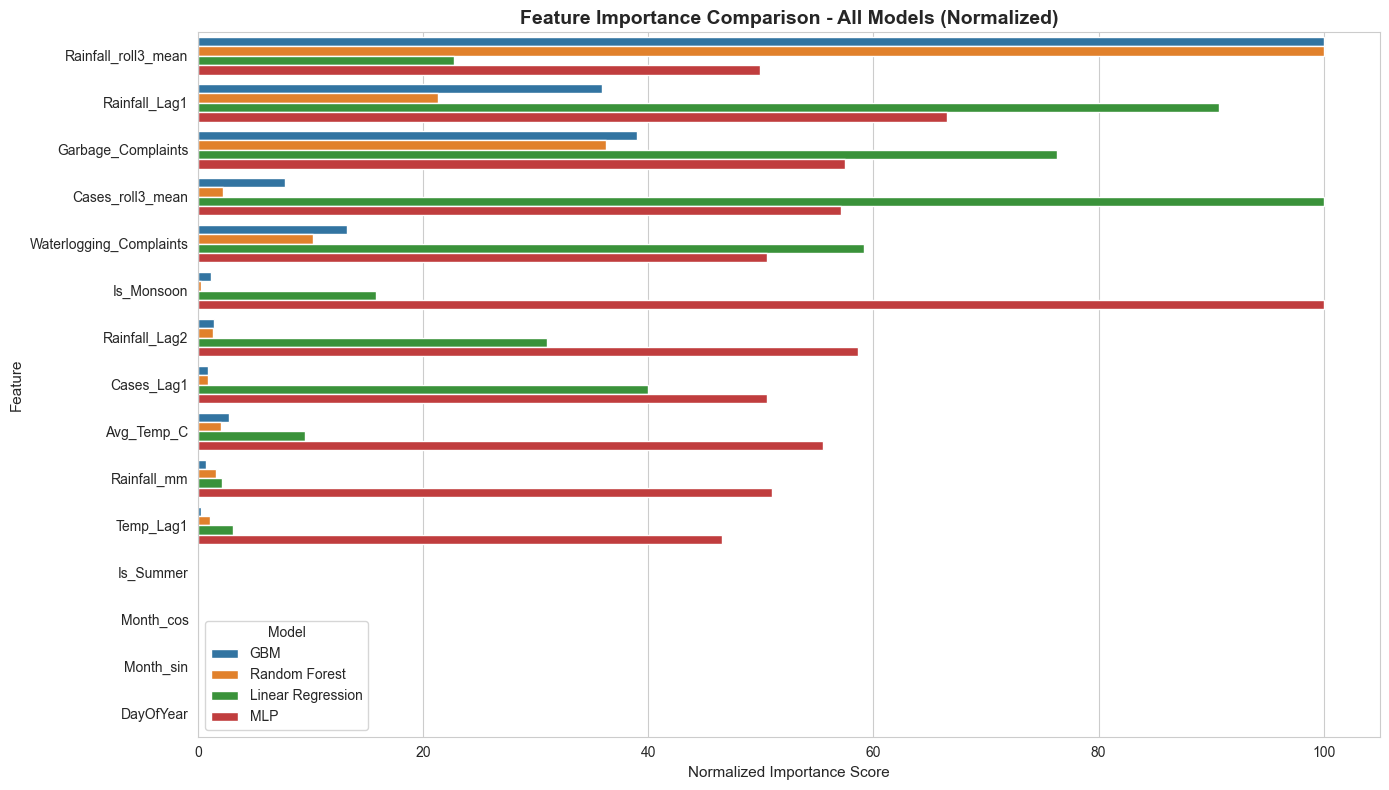


Average Feature Importance Across All Models (Top 15):
Rainfall_roll3_mean        68.168051
Rainfall_Lag1              53.615363
Garbage_Complaints         52.242596
Cases_roll3_mean           41.776482
Waterlogging_Complaints    33.288879
Is_Monsoon                 29.298875
Rainfall_Lag2              23.075203
Cases_Lag1                 23.069517
Avg_Temp_C                 17.463776
Rainfall_mm                13.840903
Temp_Lag1                  12.730063
Is_Summer                   0.000000
Month_cos                   0.000000
Month_sin                   0.000000
DayOfYear                   0.000000
dtype: float64


In [6]:
# Create normalized importance scores for comparison
normalized_importances = {}

# Helper to safe-normalize a series to 0-100 (handles constant-zero)
def normalize_series(s: pd.Series) -> pd.Series:
    if s.max() == 0 or np.isnan(s.max()):
        return pd.Series(np.zeros_like(s), index=s.index)
    return (s / s.max()) * 100

# Tree-based models
for model_name in ['GBM', 'XGBoost', 'Random Forest']:
    if model_name in models:
        model = models[model_name]
        importances = getattr(model, 'feature_importances_', None)
        if importances is None:
            continue
        model_feature_names = getattr(model, 'feature_names_in_', None)
        if model_feature_names is None:
            # try df_engineered columns or all_features fallback
            if len(importances) == len(df_engineered.columns):
                model_feature_names = list(df_engineered.columns)
            elif len(importances) == len(all_features):
                model_feature_names = all_features
            else:
                model_feature_names = [f'feat_{i}' for i in range(len(importances))]

        s = pd.Series(importances, index=model_feature_names)
        # Reindex to full feature set so comparison uses consistent index, missing -> 0
        s_full = s.reindex(all_features, fill_value=0)
        normalized_importances[model_name] = normalize_series(s_full)

# Linear Regression (coefficients)
if 'Linear Regression' in models:
    lr = models['Linear Regression']
    coef = getattr(lr, 'coef_', None)
    if coef is not None:
        model_feature_names = getattr(lr, 'feature_names_in_', None)
        if model_feature_names is None:
            if len(coef) == len(all_features):
                model_feature_names = all_features
            elif len(coef) == len(df_engineered.columns):
                model_feature_names = list(df_engineered.columns)
            else:
                model_feature_names = [f'feat_{i}' for i in range(len(coef))]
        s = pd.Series(np.abs(coef), index=model_feature_names)
        s_full = s.reindex(all_features, fill_value=0)
        normalized_importances['Linear Regression'] = normalize_series(s_full)

# MLP and other models: attempt coefficient or permutation importances if available
if 'MLP' in models:
    mlp = models['MLP']
    coef = getattr(mlp, 'coefs_', None)
    if coef is not None:
        # scikit-learn MLP stores list of layer weight matrices; approximate feature importances by input weights L2-norm
        input_weights = coef[0]  # shape (n_features, n_neurons)
        w_norm = np.linalg.norm(input_weights, axis=1)
        model_feature_names = getattr(mlp, 'feature_names_in_', None)
        if model_feature_names is None and len(w_norm) == len(all_features):
            model_feature_names = all_features
        elif model_feature_names is None:
            model_feature_names = [f'feat_{i}' for i in range(len(w_norm))]
        s = pd.Series(w_norm, index=model_feature_names)
        s_full = s.reindex(all_features, fill_value=0)
        normalized_importances['MLP'] = normalize_series(s_full)

# If no models produced normalized_importances, raise a helpful message
if not normalized_importances:
    raise RuntimeError('No model importances/coefficients could be extracted. Check model objects.')

# Get top 15 features based on average importance
avg_importance = pd.DataFrame(normalized_importances).mean(axis=1).sort_values(ascending=False).head(15)

# Create comparison plot
fig, ax = plt.subplots(figsize=(14, 8))

comparison_data = []
for model_name in normalized_importances.keys():
    for feature in avg_importance.index:
        comparison_data.append({
            'Feature': feature,
            'Model': model_name,
            'Importance': normalized_importances[model_name][feature]
        })

comparison_df = pd.DataFrame(comparison_data)

# Plot using seaborn
sns.barplot(data=comparison_df, x='Importance', y='Feature', hue='Model', ax=ax)
ax.set_title('Feature Importance Comparison - All Models (Normalized)', fontsize=14, fontweight='bold')
ax.set_xlabel('Normalized Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

print("\nAverage Feature Importance Across All Models (Top 15):")
print(avg_importance)

## 4. Feature Importance Comparison Across All Models

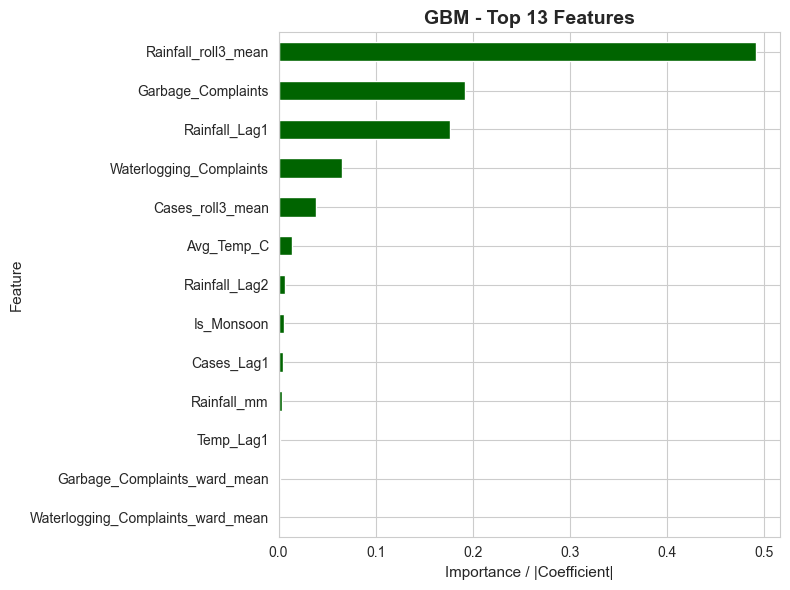


GBM - Top 13 Features:

Rainfall_roll3_mean                  0.491639
Garbage_Complaints                   0.191639
Rainfall_Lag1                        0.176554
Waterlogging_Complaints              0.065030
Cases_roll3_mean                     0.038106
Avg_Temp_C                           0.013433
Rainfall_Lag2                        0.006893
Is_Monsoon                           0.005601
Cases_Lag1                           0.004519
Rainfall_mm                          0.003234
Temp_Lag1                            0.001281
Garbage_Complaints_ward_mean         0.001153
Waterlogging_Complaints_ward_mean    0.000917
dtype: float64

------------------------------------------------------------

XGBoost not loaded — skipping.


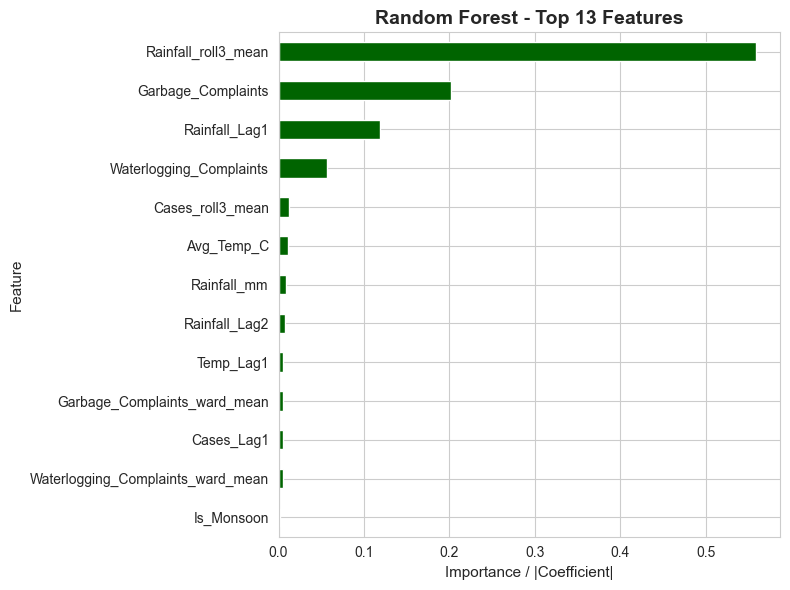


Random Forest - Top 13 Features:

Rainfall_roll3_mean                  0.558968
Garbage_Complaints                   0.202380
Rainfall_Lag1                        0.119177
Waterlogging_Complaints              0.056891
Cases_roll3_mean                     0.012476
Avg_Temp_C                           0.011515
Rainfall_mm                          0.008968
Rainfall_Lag2                        0.007128
Temp_Lag1                            0.005654
Garbage_Complaints_ward_mean         0.005253
Cases_Lag1                           0.005106
Waterlogging_Complaints_ward_mean    0.004863
Is_Monsoon                           0.001620
dtype: float64

------------------------------------------------------------



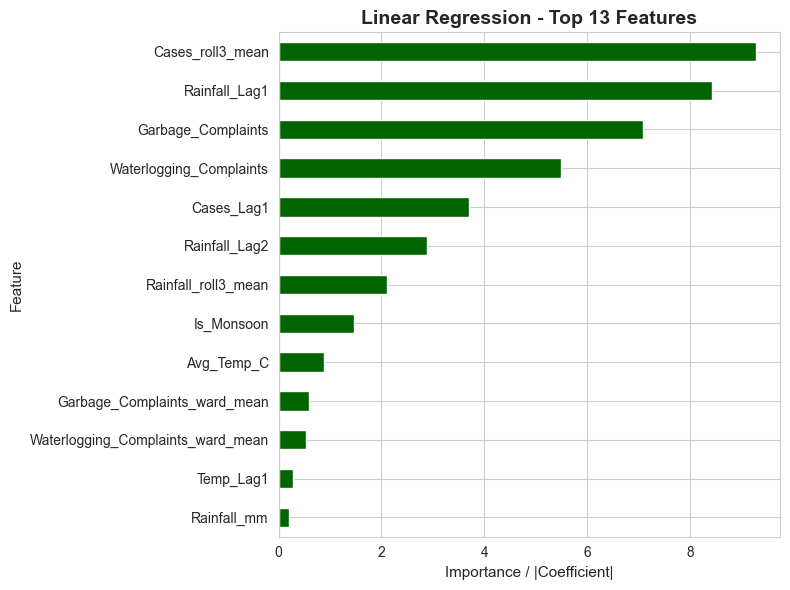


Linear Regression - Top 13 Features:

Cases_roll3_mean                     9.279988
Rainfall_Lag1                        8.413487
Garbage_Complaints                   7.078062
Waterlogging_Complaints              5.492695
Cases_Lag1                           3.704846
Rainfall_Lag2                        2.876853
Rainfall_roll3_mean                  2.108912
Is_Monsoon                           1.463133
Avg_Temp_C                           0.883621
Garbage_Complaints_ward_mean         0.584061
Waterlogging_Complaints_ward_mean    0.525672
Temp_Lag1                            0.289142
Rainfall_mm                          0.198152
dtype: float64

------------------------------------------------------------



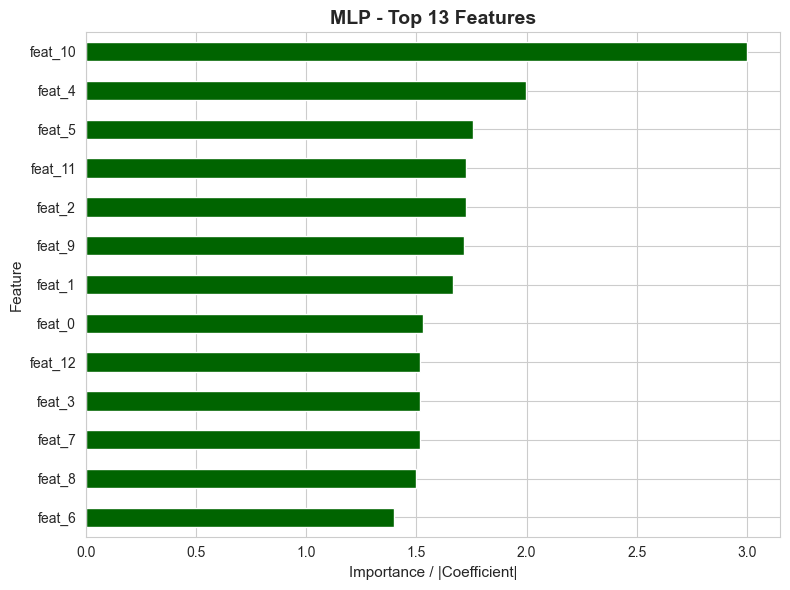


MLP - Top 13 Features:

feat_10    3.000277
feat_4     1.997176
feat_5     1.758850
feat_11    1.725732
feat_2     1.725531
feat_9     1.713854
feat_1     1.666385
feat_0     1.529123
feat_12    1.517026
feat_3     1.516992
feat_7     1.515813
feat_8     1.498543
feat_6     1.396101
dtype: float64

------------------------------------------------------------



In [12]:
# Per-model individual top-15 feature plots (one figure per model)
models_to_plot = ['GBM', 'XGBoost', 'Random Forest', 'Linear Regression', 'MLP']

for model_name in models_to_plot:
    if model_name not in models:
        print(f"{model_name} not loaded — skipping.")
        continue

    model = models[model_name]

    # Try tree-based feature_importances_
    importances = getattr(model, 'feature_importances_', None)
    if importances is not None:
        model_feature_names = getattr(model, 'feature_names_in_', None)
        if model_feature_names is None:
            # try df_engineered columns if lengths match
            if len(importances) == len(df_engineered.columns):
                model_feature_names = list(df_engineered.columns)
            elif len(importances) == len(all_features):
                model_feature_names = all_features
            else:
                model_feature_names = [f'feat_{i}' for i in range(len(importances))]

        s = pd.Series(importances, index=model_feature_names).sort_values(ascending=False).head(15)

    else:
        # Try linear coefficients
        coef = getattr(model, 'coef_', None)
        if coef is not None:
            model_feature_names = getattr(model, 'feature_names_in_', None)
            if model_feature_names is None:
                if len(coef) == len(all_features):
                    model_feature_names = all_features
                elif len(coef) == len(df_engineered.columns):
                    model_feature_names = list(df_engineered.columns)
                else:
                    model_feature_names = [f'feat_{i}' for i in range(len(coef))]
            s = pd.Series(np.abs(coef), index=model_feature_names).sort_values(ascending=False).head(15)
        else:
            # Try MLP input weights
            coefs_list = getattr(model, 'coefs_', None)
            if coefs_list is not None and len(coefs_list) > 0:
                input_weights = coefs_list[0]
                w_norm = np.linalg.norm(input_weights, axis=1)
                model_feature_names = getattr(model, 'feature_names_in_', None)
                if model_feature_names is None and len(w_norm) == len(all_features):
                    model_feature_names = all_features
                elif model_feature_names is None and len(w_norm) == len(df_engineered.columns):
                    model_feature_names = list(df_engineered.columns)
                else:
                    model_feature_names = [f'feat_{i}' for i in range(len(w_norm))]
                s = pd.Series(w_norm, index=model_feature_names).sort_values(ascending=False).head(15)
            else:
                print(f"No usable importance/coefficient info for {model_name}; skipping.")
                continue

    # Plot
    plt.figure(figsize=(8, 6))
    ax = s.sort_values().plot(kind='barh', color='darkgreen')
    ax.set_title(f'{model_name} - Top {len(s)} Features', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance / |Coefficient|', fontsize=11)
    ax.set_ylabel('Feature', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Print top feature list
    print(f"\n{model_name} - Top {len(s)} Features:\n")
    print(s.head(15))
    print("\n" + "-"*60 + "\n")

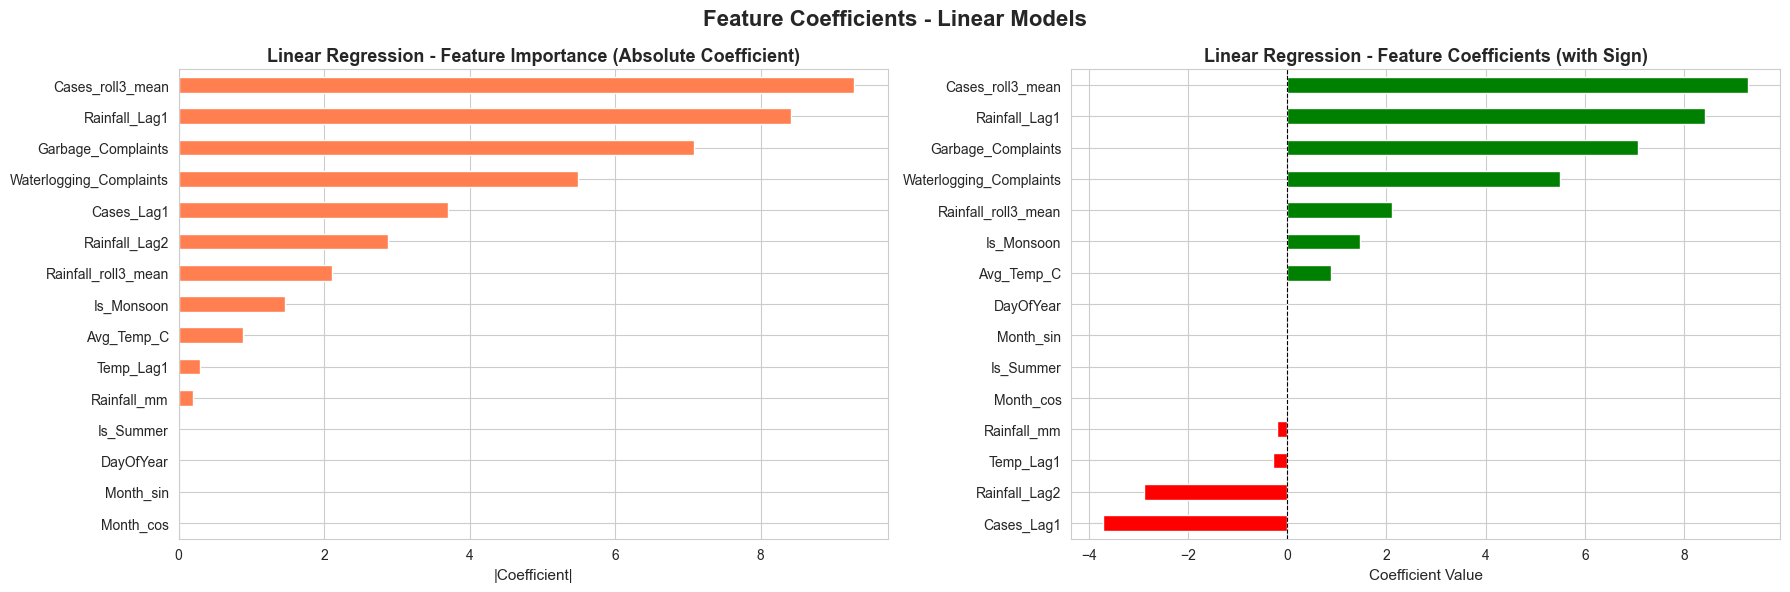

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [8]:
# Linear Regression coefficients (robust to different feature sets)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Feature Coefficients - Linear Models', fontsize=16, fontweight='bold')

linear_models = ['Linear Regression']

for idx, model_name in enumerate(linear_models):
    if model_name in models:
        model = models[model_name]
        
        # Get coefficients
        coefficients = getattr(model, 'coef_', None)
        if coefficients is None:
            print(f"{model_name} has no 'coef_' attribute; skipping.")
            continue
        
        # Determine feature names used by the model
        model_feature_names = getattr(model, 'feature_names_in_', None)
        if model_feature_names is None:
            if len(coefficients) == len(all_features):
                model_feature_names = all_features
            elif len(coefficients) == len(df_engineered.columns):
                model_feature_names = list(df_engineered.columns)
            else:
                model_feature_names = [f'feat_{i}' for i in range(len(coefficients))]

        # Create series and reindex to the full feature list (missing -> 0)
        coef_series = pd.Series(coefficients, index=model_feature_names)
        coef_full = coef_series.reindex(all_features, fill_value=0)
        coef_series_sorted = coef_full.abs().sort_values(ascending=False).head(15)
        
        # Get actual values with signs for the selected features
        coef_values = coef_full[coef_series_sorted.index]
        
        # Plot absolute values
        ax = axes[0]
        coef_series_sorted.sort_values().plot(kind='barh', ax=ax, color='coral')
        ax.set_title('Linear Regression - Feature Importance (Absolute Coefficient)', fontsize=13, fontweight='bold')
        ax.set_xlabel('|Coefficient|', fontsize=11)
        
        # Plot with signs
        ax = axes[1]
        colors = ['green' if x > 0 else 'red' for x in coef_values.sort_values().values]
        coef_values.sort_values().plot(kind='barh', ax=ax, color=colors)
        ax.set_title('Linear Regression - Feature Coefficients (with Sign)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Coefficient Value', fontsize=11)
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# Print top features
if 'Linear Regression' in models:
    lr_model = models['Linear Regression']
    coef_series = pd.Series(getattr(lr_model, 'coef_', None), index=(getattr(lr_model, 'feature_names_in_', None) or all_features[:len(getattr(lr_model, 'coef_', []))]))
    coef_full = coef_series.reindex(all_features, fill_value=0)
    
    print("\nLinear Regression - Top 10 Features (by absolute coefficient):")
    top_features = coef_full.abs().sort_values(ascending=False).head(10)
    for feat in top_features.index:
        print(f"  {feat}: {coef_full[feat]:.6f}")

## 3. Feature Coefficients - Linear Models

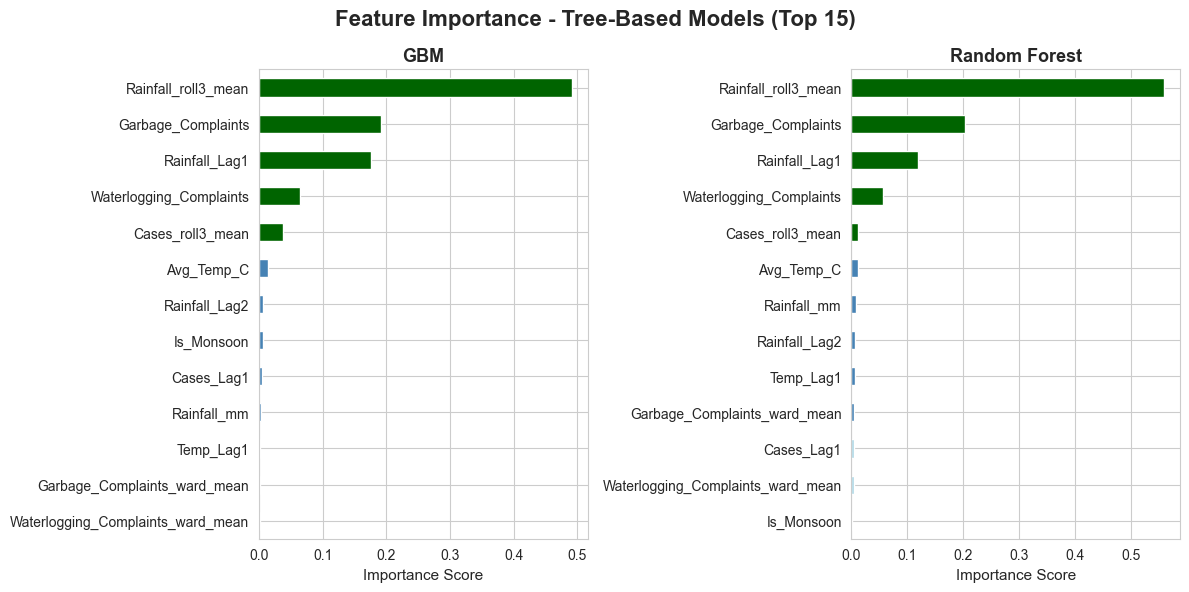


GBM - Top 10 Features:
Rainfall_roll3_mean        0.491639
Garbage_Complaints         0.191639
Rainfall_Lag1              0.176554
Waterlogging_Complaints    0.065030
Cases_roll3_mean           0.038106
Avg_Temp_C                 0.013433
Rainfall_Lag2              0.006893
Is_Monsoon                 0.005601
Cases_Lag1                 0.004519
Rainfall_mm                0.003234
dtype: float64

Random Forest - Top 10 Features:
Rainfall_roll3_mean             0.558968
Garbage_Complaints              0.202380
Rainfall_Lag1                   0.119177
Waterlogging_Complaints         0.056891
Cases_roll3_mean                0.012476
Avg_Temp_C                      0.011515
Rainfall_mm                     0.008968
Rainfall_Lag2                   0.007128
Temp_Lag1                       0.005654
Garbage_Complaints_ward_mean    0.005253
dtype: float64


In [5]:
# Feature importance for tree-based models
tree_models = ['GBM', 'XGBoost', 'Random Forest']
feature_importances = {}

# Prepare subplot grid sized by available models
available_tree_models = [m for m in tree_models if m in models]
n = max(1, len(available_tree_models))
fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
if n == 1:
    axes = [axes]
fig.suptitle('Feature Importance - Tree-Based Models (Top 15)', fontsize=16, fontweight='bold')

for idx, model_name in enumerate(available_tree_models):
    model = models[model_name]

    importances = getattr(model, 'feature_importances_', None)
    if importances is None:
        print(f"{model_name} has no attribute 'feature_importances_'; skipping.")
        continue

    # Determine feature names for this model; fall back safely
    model_feature_names = getattr(model, 'feature_names_in_', None)
    if model_feature_names is None:
        if len(importances) == len(all_features):
            model_feature_names = all_features
        else:
            # If the model was trained on a subset, try to infer from df_engineered columns
            cols = list(df_engineered.columns)
            if len(importances) == len(cols):
                model_feature_names = cols
            else:
                model_feature_names = [f'feat_{i}' for i in range(len(importances))]

    # Create series, reindex to model's own features
    importance_series = pd.Series(importances, index=model_feature_names).sort_values(ascending=False).head(15)
    feature_importances[model_name] = importance_series

    ax = axes[idx]
    importance_series.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=11)

    # Highlight top 5 (from the plotted series)
    top_n = 5
    patches = ax.patches
    for i, patch in enumerate(patches[::-1]):
        # patches are drawn in ascending order on horizontal bar; reverse to color top bars
        if i < top_n:
            patch.set_facecolor('darkgreen')
        elif i < 10:
            patch.set_facecolor('steelblue')
        else:
            patch.set_facecolor('lightblue')

plt.tight_layout()
plt.show()

# Print top 10 features for each model
for model_name, series in feature_importances.items():
    print(f"\n{model_name} - Top 10 Features:")
    print(series.head(10))

## 2. Feature Importance for Tree-Based Models (Top 15 Features)

In [3]:
# Load all models
models = {}
model_files = {
    'GBM': 'model_gbm_final.joblib',
    'XGBoost': 'model_xgboost_final.joblib',
    'Random Forest': 'model_random_forest_final.joblib',
    'Linear Regression': 'model_linear_regression_final.joblib',
    'MLP': 'model_mlp_final.joblib'
}

for model_name, file_path in model_files.items():
    try:
        models[model_name] = joblib.load(file_path)
        print(f"✓ Loaded {model_name} model")
    except Exception as e:
        print(f"✗ Could not load {model_name}: {e}")

print(f"\nSuccessfully loaded {len(models)} models")

✓ Loaded GBM model
✗ Could not load XGBoost: No module named 'xgboost'
✓ Loaded Random Forest model
✓ Loaded Linear Regression model
✓ Loaded MLP model

Successfully loaded 4 models


## 1. Load All Trained Models

In [2]:
# Load feature engineering information
with open('feature_engineering_info.json', 'r') as f:
    feature_info = json.load(f)

# Load engineered features dataset
df_engineered = pd.read_csv('engineered_features_dataset.csv')
print(f"Engineered dataset shape: {df_engineered.shape}")
print(f"\nFeature categories: {list(feature_info['feature_categories'].keys())}")

# Get all features
all_features = feature_info['all_features']
feature_categories = feature_info['feature_categories']
print(f"\nTotal features: {len(all_features)}")
print(f"Features breakdown:")
for category, features in feature_categories.items():
    print(f"  - {category}: {len(features)} features")

Engineered dataset shape: (6534, 37)

Feature categories: ['raw', 'temporal', 'lag', 'rolling', 'aggregation']

Total features: 35
Features breakdown:
  - raw: 4 features
  - temporal: 9 features
  - lag: 10 features
  - rolling: 9 features
  - aggregation: 4 features


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Feature Engineering Visualizations - All Models
This notebook generates comprehensive visualization graphs for all feature engineering models.